# --------------------- road Description ----------------------------
  		 road.length =  2750
  		 minimum slope (descending) =  -3.2174072638526923
  		 maximum slope (ascending)  =   3.456286285863712
# -----------------------------------------------------------------
FixScalerCenteredMax self.offset 25.0


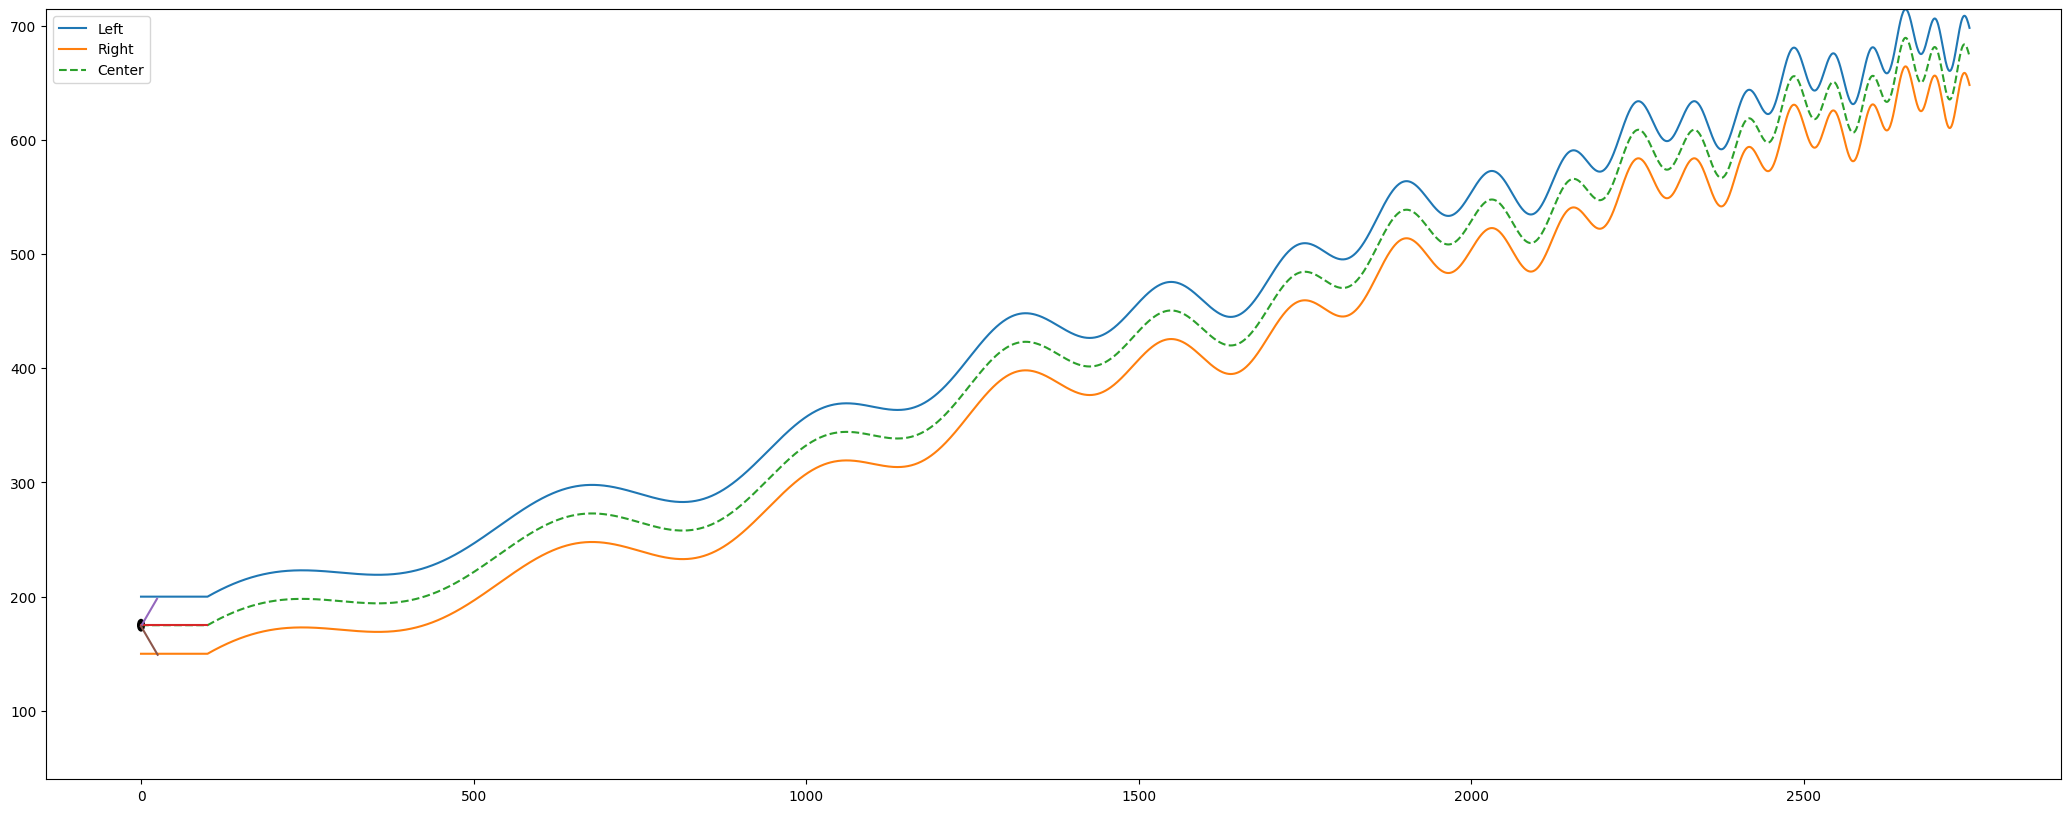

FixScalerCenteredMax self.offset 25.0
# 0 run metódus futási ideje: 34.614 másodperc
cum sum err vége: 11647.42


In [7]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm

from matplotlib.colors import Normalize
from matplotlib import cm

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import QuantileTransformer

from sklearn.metrics import r2_score, explained_variance_score, mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers

import torch
import torch.nn as nn
import torch.optim as optim

import gc
import os
import copy
import glob
import time
import pickle
import random

from ipywidgets import interact, interactive, fixed, interact_manual, HBox, VBox, Layout
import ipywidgets as widgets
from IPython.display import display

from IPython.display import clear_output

from rich.progress import track

import warnings
warnings.filterwarnings('ignore')

def set_global_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    # Ha GPU-t is használnál:
    # torch.cuda.manual_seed_all(seed)
    # torch.backends.cudnn.deterministic = True
    # torch.backends.cudnn.benchmark = False

class NoScaler:
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X

    def inverse_transform(self, X):
        return X

class FixScaler:
    def __init__(self, value=100):
        self.value = value

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X / self.value

    def inverse_transform(self, X):
        return X * self.value

class FixScalerCenteredMax:
    def __init__(self, value=100, maximum=0):
        self.value = value
        self.maximum = maximum
        self.offset = maximum / 2
        print('FixScalerCenteredMax self.offset', self.offset)

    def fit(self, X, y=None):
        return self  # nincs tanulás

    def transform(self, X):
        return (X - self.offset) / self.value
    
    def inverse_transform(self, X):
        return X * self.value + self.offset
    
class CutScaler:
    def __init__(self, min_val=-1.0, max_val=1.0):
        self.min_val = min_val
        self.max_val = max_val

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = np.array(X)
        return np.clip(X, self.min_val, self.max_val)

    def inverse_transform(self, X):
        return np.array(X)


class ReciprocalScaler:
    def __init__(self, epsilon=1e-8):
        self.epsilon = epsilon

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = np.array(X)
        return 1.0 / (X + self.epsilon)

    def inverse_transform(self, X):
        X = np.array(X)
        return 1.0 / X - self.epsilon

class LogScaler:
    def __init__(self, epsilon=1e-4):
        self.epsilon = epsilon

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = np.array(X)
        return np.log(X + self.epsilon)

    def transform(self, X):
        X = np.array(X)
        return np.log(np.maximum(X + self.epsilon, 1e-8))

    def inverse_transform(self, X):
        X = np.array(X)
        return np.exp(X) - self.epsilon

class SignedLogScaler:
    def __init__(self, epsilon=1e-4):
        self.epsilon = epsilon

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = np.array(X)
        return np.sign(X) * np.log(np.abs(X) + self.epsilon)

    def inverse_transform(self, X):
        X = np.array(X)
        return np.sign(X) * (np.exp(np.abs(X)) - self.epsilon)

class FixScalerCentered:
    def __init__(self, value=100, offset=0):
        self.value = value
        self.offset = offset

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X / self.value - self.offset

    def inverse_transform(self, X):
        return (X + self.offset) * self.value

class Plotter():

    def __init__(self):
        self.ildi = "Szexi"
        pass

class Platter():
    
    def __init__(self):
        self.car = None
        pass
    
    def plot_history(self, car, flag, show_y_distance = False, grid = False):
        if (flag != 0):
            fig, ax = car.road.show()
            circle = plt.Circle((car.x, car.y), 5, color='black')
            ax.add_patch(circle)
            ax.plot(
                range(int(car.x),
                      int(car.x + car.distance_center_from_wall)),
                np.repeat(car.y, car.distance_center_from_wall))
            ax.plot(
                range(int(car.x), int(car.x + car.distance_left_from_wall)),
                range(int(car.y), int(car.y + car.distance_left_from_wall)))
            ax.plot(
                range(int(car.x),
                      int(car.x + car.distance_right_from_wall)),
                range(int(car.y), int(car.y - car.distance_right_from_wall),
                      -1))
            
            if show_y_distance == True:
                __ = 500
                ax.plot(np.array(car.y_distance) + __, label='y_distance') 
                ax.axhline(__, color='black', lw=1.0, ls='--')
                ax.legend()
                
            if (len(car.y_history) > 0):
                ax.plot(car.y_history)
                ax.set_title('#i = ' + str(car.x),
                             fontsize=18,
                             fontweight='bold')
            
            if car.plot_y_min != None and car.plot_y_max != None:
                ax.set_ylim(car.plot_y_min, car.plot_y_max)
                
            if grid == True:
                plt.grid()
            
            if (flag == 1 or flag == 3): plt.show()
            if (flag == 2 or flag == 3):
                fig.savefig('history{0:04}'.format(car.x) + '.png')
                plt.close('all')
                fig.clf()
                ax.cla()
                plt.close('all')


class Printer():

    def __init__(self):
        self._nn = True   # Neural Network
        self._lr = False  # Linear Regression on Before After
        self._sr = False  # Sensor Data
        self._ba = False  # Before After Data
        self._nf = False  # Print Info
        self._db = False  # Print Debug
        self._er = True   # Print Error
        self._ut = True   # Print Util
        self._bs = True   # Print Basic
        self._in = True   # Print Investigation
        self._ac = False  # Print Action results
        self._dc = True   # Print Decision result

    def nn(self, text, value=""):
        if (self._nn == True):
            print(text, value)

    def lr(self, text, value=""):
        if (self._lr == True):
            print(text, value)

    def sr(self, text, value=""):
        if (self._sr == True):
            print(text, value)

    def ba(self, text, value=""):
        if (self._ba == True):
            print(text, value)

    def info(self, text, value=""):
        if (self._nf == True):
            print(text, value)

    def debug(self, text, value=""):
        if (self._db == True):
            print(text, value)

    def error(self, text, value=""):
        if (self._er == True):
            print(text, value)

    def util(self, text, value=""):
        if (self._ut == True):
            print(text, value)

    def basic(self, text, value=""):
        if (self._bs == True):
            print(text, value)

    def investigation(self, text, value=""):
        if (self._in == True):
            print(text, value)

    def action(self, text, value=""):
        if (self._ac == True):
            print(text, value)

    def decision(self, text, value=""):
        if (self._dc == True):
            print(text, value)

    def nn_(self, text):
        if (self._nn == True):
            print(text)

    def lr_(self, text):
        if (self._lr == True):
            print(text)

    def sr_(self, text):
        if (self._sr == True):
            print(text)

    def ba_(self, text):
        if (self._ba == True):
            print(text)

    def info_(self, text):
        if (self._nf == True):
            print(text)

    def debug_(self, text):
        if (self._db == True):
            print(text)

    def error_(self, text):
        if (self._er == True):
            print(text)

    def util_(self, text):
        if (self._ut == True):
            print(text)

    def basic_(self, text):
        if (self._bs == True):
            print(text)

    def investigation_(self, text):
        if (self._in == True):
            print(text)

    def action_(self, text):
        if (self._ac == True):
            print(text)

    def decision_(self, text):
        if (self._dc == True):
            print(text)

class Storage():

    def __init__(self):
        self.name = 'Storage'
        self.pkl_mlp_filename = 'pickle_mlp.pkl'
        self.pkl_regression_filename = 'pickle_regression.pkl'
        self.pkl_minmaxscaler_filename = 'pickle_minmaxscaler.pkl'

class FastTorchMLP:
    def __init__(self,
                 input_dim,
                 output_dim=1,
                 hidden_layer_sizes=(10, 5),
                 learning_rate_init=0.01,
                 optimizer="sgd",
                 activation="tanh",
                 random_state=None):
        
        if random_state is not None:
            set_global_seed(random_state)

        self.input_dim = input_dim
        self.output_dim = output_dim
        self.hidden_layer_sizes = hidden_layer_sizes
        self.learning_rate = learning_rate_init
        self.optimizer_choice = optimizer
        self.activation_choice = activation

        self.model = self.build_model()
        self.loss_fn = nn.MSELoss()
        self.optimizer = self.build_optimizer()

    def build_model(self):
        layers = []
        in_dim = self.input_dim

        activation_fn = nn.Tanh if self.activation_choice == "tanh" else nn.ReLU

        for hidden_dim in self.hidden_layer_sizes:
            layers.append(nn.Linear(in_dim, hidden_dim))
            layers.append(activation_fn())
            in_dim = hidden_dim

        layers.append(nn.Linear(in_dim, self.output_dim))
        return nn.Sequential(*layers)

    def build_optimizer(self):
        if self.optimizer_choice == "adam":
            return optim.Adam(self.model.parameters(), lr=self.learning_rate)
        else:
            return optim.SGD(self.model.parameters(), lr=self.learning_rate)

    def fit(self, X, y):
        X_tensor = torch.tensor(X, dtype=torch.float32)
        y_tensor = torch.tensor(y, dtype=torch.float32)

        self.model.train()
        self.optimizer.zero_grad()
        output = self.model(X_tensor)
        loss = self.loss_fn(output, y_tensor)
        loss.backward()
        self.optimizer.step()

    def predict(self, X):
        X_tensor = torch.tensor(X, dtype=torch.float32)
        self.model.eval()
        with torch.no_grad():
            pred = self.model(X_tensor)
        return pred.numpy().reshape(-1, 1)

class Car():

    def __init__(self, road, plotter, platter, storage, settings=None):
        self.plot_frequency                           = 9
        self.plot_detailed_frequency                  = 32
        self.plot_history_flag                        = 0   # 0 - disable, 1 - plot, 2 - save, 3 - both
        self.plot_investigation_flag                  = 0   # 0 - disable, 1 - plot, 2 - save, 3 - both
        self.plot_investigation_sensor_flag           = 0   # 0 - disable, 1 - plot, 2 - save, 3 - both
        self.plot_before_after_sensor_values_flag     = 0   # 0 - disable, 1 - plot, 2 - save, 3 - both
        self.plot_before_after_sensor_estimation_flag = 0   # 0 - disable, 1 - plot, 2 - save, 3 - both
        self.plot_state_space_discover_flag           = 0   # 0 - disable, 1 - plot, 2 - save, 3 - both
        self.plot_trace_flag                          = 0   # 0 - disable, 1 - plot, 2 - save, 3 - both
        self.plotter_flag                             = 0   # 0 - disable, 1 - plot, 2 - save, 3 - both
        self.plotter_switch                           = [6] # [] - none, [1], [1,2], [1,3], [99] - all
        self.plotter_mlp_flag                         = 0   # 0 - disable, 1 - plot, 2 - save, 3 - both
        
        self.investigation_figsize = (12, 5)
        self.investigation_in_one_figsize = (18, 4.5)
        self.investigation_in_one_figsize_7 = (18, 7.5)
        self.test_plot_figsize = (15, 5)
        
        self.dir_training = 'Training'
        
        self.plot_y_min = None
        self.plot_y_max = None
        
        self.jump_flags = []
        
        self.stop_external_move_at_i = 100
        self.external_move_value = 1
        self.dynamic_external_step = False
        
        self.artificial_jump_frequency = 300
        self.artificial_jump_value = 20

        self.digit = 5
        self.print_rate = 300

        self.hidden_layer_sizes = (10, 5)
        self.learning_rate_init = 0.01
        self.max_iter = 2
        self.solver = 'adam'
        self.activation = 'tanh'
        self.nesterovs_momentum = True
        
        self.scaler_type = 'MinMax'
        self.feature_range = (-1, 1)
        self.feature_range_centered_max_maximum = None

        self.random_state = 1
        
        # A LinearRegression Default Parameters
        self.fit_intercept = False
        
        self.ridge_regression_alpha = 1.0
        
        # Multi sensor regression estimation
        self.multi_sensor_regression = False
        
        # A lehetséges akciók lépétek (-7, .., +7)
        self.action_range = (7, 1)

        # Beállítások felülírása, ha van settings dict
        if settings:
            for key, value in settings.items():
                if hasattr(self, key):
                    setattr(self, key, value)
                else:
                    raise ValueError(f"Ismeretlen beállítás: {key}")

        self.sensor_center_enable = True

        self.plotter = plotter
        
        self.platter = platter
        
        self.platter.car = self

        self.storage = storage

        self.road = road
        self.x = 0
        self.y = self.road.wall_center[0]
        self.sight = 400
        self.sight_center = 400

        self.y_history = []
        self.x_history = []
        # self.y_center   = []
        self.y_center = self.road.wall_center
        self.y_distance = []
        self.y_distance_real = []
        self.y_distance_predicted = []
        self.y_distance_predicted_inv = []
        self.regression = LinearRegression(fit_intercept=self.fit_intercept)
        
        self.mlp = MLPRegressor(
            hidden_layer_sizes=self.hidden_layer_sizes,
            activation=self.activation,
            solver=self.solver,
            batch_size='auto',
            learning_rate_init=self.learning_rate_init,
            max_iter=self.max_iter,
            shuffle=False,
            random_state=self.random_state,
            verbose=True,
            warm_start=True,
            momentum=0.9,
            nesterovs_momentum=self.nesterovs_momentum,
            early_stopping=False,
            n_iter_no_change=9000000)
        
        # Tensorflow

        
        set_global_seed(self.random_state)
        self.mlp = FastTorchMLP(input_dim = 3,
                             hidden_layer_sizes = self.hidden_layer_sizes,
                             learning_rate_init = self.learning_rate_init,
                             optimizer = self.solver,
                             activation = self.activation,
                             random_state = self.random_state)

        if self.scaler_type == 'MinMax':
            self.x_minmaxscaler = MinMaxScaler(feature_range=self.feature_range)
            self.y_minmaxscaler = MinMaxScaler(feature_range=self.feature_range)
        
        if self.scaler_type == 'Standard':
            self.x_minmaxscaler = StandardScaler()
            self.y_minmaxscaler = StandardScaler()

        if self.scaler_type == 'Log':
            self.x_minmaxscaler = LogScaler()
            self.y_minmaxscaler = MinMaxScaler(feature_range=self.feature_range)

        if self.scaler_type == 'SignedLog':
            self.x_minmaxscaler = SignedLogScaler()
            self.y_minmaxscaler = SignedLogScaler()

        if self.scaler_type == 'Fix':
            self.x_minmaxscaler = FixScaler(self.feature_range[0])
            self.y_minmaxscaler = FixScaler(self.feature_range[1])

        if self.scaler_type == 'FixCenteredMax':
            self.x_minmaxscaler = FixScalerCenteredMax(self.feature_range[0], self.feature_range_centered_max_maximum)
            self.y_minmaxscaler = FixScaler(self.feature_range[1])

        if self.scaler_type == 'Reciprocal':
            self.x_minmaxscaler = ReciprocalScaler()
            self.y_minmaxscaler = MinMaxScaler(feature_range=self.feature_range)

        if self.scaler_type == 'Robust':
            self.x_minmaxscaler = RobustScaler(quantile_range=self.feature_range)
            self.y_minmaxscaler = RobustScaler(quantile_range=self.feature_range)

        if self.scaler_type == 'Quantile':
            self.x_minmaxscaler = QuantileTransformer()
            self.y_minmaxscaler = QuantileTransformer()

        if self.scaler_type == 'None':
            self.x_minmaxscaler = NoScaler()
            self.y_minmaxscaler = NoScaler()
        
        self.regression_left = LinearRegression(fit_intercept=self.fit_intercept)
        self.regression_center = LinearRegression(fit_intercept=self.fit_intercept)
        self.regression_right = LinearRegression(fit_intercept=self.fit_intercept)
        
        self.regression = Ridge(alpha=self.ridge_regression_alpha, fit_intercept=self.fit_intercept)
        self.regression_left = Ridge(alpha=self.ridge_regression_alpha, fit_intercept=self.fit_intercept)
        self.regression_center = Ridge(alpha=self.ridge_regression_alpha, fit_intercept=self.fit_intercept)
        self.regression_right = Ridge(alpha=self.ridge_regression_alpha, fit_intercept=self.fit_intercept)

        # data holders
        self.sensor_center = []
        self.sensor_left = []
        self.sensor_right = []
        self.before = []
        self.after = []

        # new v.25
        # model data holders
        self.regression_left_coef_history = []
        self.regression_center_coef_history = []
        self.regression_right_coef_history = []

        self.mesterseges_coutner = 0

        global printer
        printer = Printer()
        
        printer._db = False
        printer._sr = False

    def calculate_distances(self):

        k = self.x
        d = 0
        while (k < self.x + self.sight_center):
            k += 1
            d += 1
            self.distance_center_from_wall = d
            # v.24 - new
            if (self.sensor_center_enable == True):
                if (int(self.road.wall_left[k]) < self.y):
                    printer.sr('Sensor center          = ',
                               self.distance_center_from_wall)
                    break
                if (int(self.road.wall_right[k]) > self.y):
                    printer.sr('Sensor center          = ',
                               self.distance_center_from_wall)
                    break
        else:
            printer.sr('Sensor center (max)    = ', self.distance_center_from_wall)

        k = self.x
        d = 0
        while (k < self.x + self.sight):
            k += 1
            d += 1
            self.distance_left_from_wall = d
            if (int(self.road.wall_left[k]) < self.y + d):
                printer.sr('Sensor from left wall  = ',
                           self.distance_left_from_wall)
                break
        else:
            printer.sr('Sensor from left wall  = ', self.distance_left_from_wall)

        k = self.x
        d = 0
        while (k < self.x + self.sight):
            k += 1
            d += 1
            self.distance_right_from_wall = d
            if (int(self.road.wall_right[k]) > self.y - d):
                printer.sr('Sensor from right wall = ',
                           self.distance_right_from_wall)
                break
        else:
            printer.sr('Sensor from right wall = ', self.distance_right_from_wall)

        self.distance_from_top = abs(self.road.wall_left[self.x] - self.y)
        self.distance_from_bottom = abs(self.road.wall_right[self.x] - self.y)
        printer.sr('most távolsagra van a felső faltól = ',
                   self.distance_from_top)
        printer.sr('most távolsagra van az alsó faltól = ',
                   self.distance_from_bottom)

        self.vertical_distance_from_middle = self.y - self.road.wall_center[self.x]


    def append(self):
        self.y_distance.append(self.vertical_distance_from_middle)

        self.sensor_left.append(self.distance_left_from_wall)
        self.sensor_center.append(self.distance_center_from_wall)
        self.sensor_right.append(self.distance_right_from_wall)


    def save_plots(self):
        # y_distance vs y_distance_predicted
        plt.figure(figsize=(12, 5))
        plt.scatter(self.y_distance_real, self.y_distance_predicted)
        plt.ylabel('y_distance_predicted')
        plt.xlabel('y_distance_real')
        plt.title('#i = ' + str(self.x), fontsize=18, fontweight='bold')
        plt.savefig(
            'y_distance_vs_y_distance_predicted_{0:04}'.format(self.x) +
            '.png')
        plt.close()

        # y_distance vs y_distance_predicted összes adaton
        X_test_full = np.array(
            [self.sensor_left, self.sensor_center, self.sensor_right]).T
        _X_test_full = X_test_full
        _X_test_full_scaled = self.x_minmaxscaler.transform(_X_test_full)
        predicted_test_full = self.mlp.predict(_X_test_full_scaled)
        predicted_test_full = self.y_minmaxscaler.inverse_transform(
            predicted_test_full.reshape(-1, 1))
        _y_test_full = np.array([self.y_distance]).T
        plt.figure(figsize=(12, 5))
        plt.scatter(_y_test_full, predicted_test_full, c='r')
        plt.ylabel('y_distance_predicted')
        plt.xlabel('y_distance_real')
        plt.title('#i = ' + str(self.x), fontsize=18, fontweight='bold')
        plt.savefig(
            'y_distance_vs_y_distance_predicted_all_{0:04}'.format(self.x) +
            '.png')
        plt.close()

        # y_distance vs y_distance_predicted összes adaton színezve
        _array_target = np.array([
            _y_test_full.ravel(),
            predicted_test_full.ravel(),
            np.arange(0, _y_test_full.shape[0], 1)
        ]).T

        plt.figure(figsize=(12, 5))
        plt.scatter(_array_target[:, 0],
                    _array_target[:, 1],
                    c=_array_target[:, 2])
        plt.ylabel('y_distance_predicted')
        plt.xlabel('y_distance_real')
        plt.title('#i = ' + str(self.x), fontsize=18, fontweight='bold')
        plt.savefig('y_distance_vs_y_distance_predicted_all_color_{0:04}'.
                    format(self.x) + '.png')
        plt.close()

        # y_distance vs y_distance_predicted összes adaton színezve vezető vonallal
        plt.figure(figsize=(12, 5))
        ax = plt.axes()
        ax.scatter(_array_target[:, 0],
                   _array_target[:, 1],
                   c=_array_target[:, 2])
        ax.plot([-10, 2, 4, 10], [-10, 2, 4, 10])
        ax.set_ylabel('y_distance_predicted')
        ax.set_xlabel('y_distance_real')
        ax.set_title('#i = ' + str(self.x), fontsize=18, fontweight='bold')
        plt.savefig('y_distance_vs_y_distance_predicted_all_color_line_{0:04}'.
                    format(self.x) + '.png')
        plt.close()

        # Milyen kapcsolat van a bemenő adatok és a célváltozó között
        plt.figure(figsize=(12, 5))
        plt.scatter(self.sensor_left, self.y_distance, c=_array_target[:, 2])
        plt.ylabel('self.y_distance')
        plt.xlabel('self.sensor_left')
        plt.title('#i = ' + str(self.x), fontsize=18, fontweight='bold')
        plt.savefig('sensor_left_vs_y_distance_{0:04}'.format(self.x) + '.png')
        plt.close()

        # y_distance vs y_distance_predicted összes adaton színezve vezető vonallal
        plt.figure(figsize=(12, 5))
        ax = plt.axes()
        ax.scatter(_array_target[:, 0],
                   _array_target[:, 1],
                   c=_array_target[:, 2])
        ax.plot([-10, 2, 4, 10], [-10, 2, 4, 10])
        ax.set_ylabel('y_distance_predicted')
        ax.set_xlabel('y_distance_real')
        ax.set_ylim((-30, 30))
        ax.set_xlim((-50, 50))
        ax.set_title('#i = ' + str(self.x), fontsize=18, fontweight='bold')
        plt.savefig(
            'y_distance_vs_y_distance_predicted_all_color_line_fix_{0:04}'.
            format(self.x) + '.png')
        plt.close()

        print(' --- plots have been saved --- ')

    def run(self, run_length, artificial_jump=False):
        pass


class ConstantActionCar(Car):
    def __init__(self, road, plotter, platter, storage, settings=None,
                 override_start_i=None, override_end_i=None, override_value=1,
                 artificial_jump_interval=3):
        super().__init__(road, plotter, platter, storage, settings)
        self.override_start_i = override_start_i
        self.override_end_i = override_end_i
        self.override_value = override_value

        self.artificial_jump_interval = artificial_jump_interval
        self.last_jump_direction = 1


    def run(self, run_length, artificial_jump=False):
        
        __ = 0
        
        for i in range(0, run_length, 1):
            
            if i % 1000 == 0:
                gc.collect()
            
            if i % 100 == 0:
                printer.util('# i = ', i)
            
            self.x = i
            
            # self.calculate_distances()

            # --- 1. DÖNTÉS és MOZGÁS (mesterséges vagy modell alapú) ---
            if i < self.stop_external_move_at_i and i % 2 == 0:
                
                if self.dynamic_external_step == True:
                    if i % 4 == 0:
                        __ += 1
                    self.external_move_value = __
                    pass

                self.before.append(np.array([
                    self.y,
                    self.distance_left_from_wall,
                    self.distance_center_from_wall,
                    self.distance_right_from_wall
                ]))

                if self.mesterseges_coutner == 0:
                    self.y += self.external_move_value
                    self.mesterseges_coutner = 1
                elif self.mesterseges_coutner == 1:
                    self.y -= self.external_move_value
                    self.mesterseges_coutner = 2
                elif self.mesterseges_coutner == 2:
                    self.y -= self.external_move_value
                    self.mesterseges_coutner = 3
                elif self.mesterseges_coutner == 3:
                    self.y += self.external_move_value
                    self.mesterseges_coutner = 0

                self.calculate_distances()

                self.after.append(np.array([
                    self.y,
                    self.distance_left_from_wall,
                    self.distance_center_from_wall,
                    self.distance_right_from_wall
                ]))

            else:
                # Modell alapú döntés és léptetés
                action = 0
                
                if len(self.before) > 19:
                    best_score = float('inf')
                    best_action = 0
                    
                    # Lineáris regresszió kiszámolás az aktuális adatokon (ez egyben tanítás is)
                    before_array = np.array(self.before)
                    after_array = np.array(self.after)
                    y_delta = after_array[:, 0] - before_array[:, 0]
                    delta_array = after_array - before_array

                    # -------------- left
                    if self.multi_sensor_regression:
                        _X_left = np.array([
                            before_array[:, 1],  # left
                            before_array[:, 2],  # center
                            before_array[:, 3],  # right
                            delta_array[:, 0],   # delta_y
                        ]).T
                    else:
                        _X_left = np.array([
                            before_array[:, 1],  # left
                            delta_array[:, 0],   # delta_y
                        ]).T

                    _y_left = after_array[:, 1].reshape(-1, 1)
                    self.regression_left.fit(_X_left, _y_left)
                    
                    _predicted_left = self.regression_left.predict(_X_left)
                    
                    # -------------- center
                    if self.multi_sensor_regression:
                        _X_center = np.array([
                            before_array[:, 1],  # left
                            before_array[:, 2],  # center
                            before_array[:, 3],  # right
                            delta_array[:, 0],   # delta_y
                        ]).T
                    else:
                        _X_center = np.array([
                            before_array[:, 2],  # center
                            delta_array[:, 0],   # delta_y
                            ]).T  # center és delta_y (before)

                    _y_center = after_array[:, 2].reshape(-1, 1)  # center (after)
                    self.regression_center.fit(_X_center, _y_center)
                    
                    _predicted_center = self.regression_center.predict(_X_center)
                    
                    if self.multi_sensor_regression:
                        _X_right = np.array([
                            before_array[:, 1],  # left
                            before_array[:, 2],  # center
                            before_array[:, 3],  # right
                            delta_array[:, 0],   # delta_y
                        ]).T
                    else:
                        _X_right = np.array([
                            before_array[:, 3],  # right
                            delta_array[:, 0],   # delta_y
                        ]).T

                    _y_right = after_array[:, 3].reshape(-1, 1)  # right (after)
                    self.regression_right.fit(_X_right, _y_right)
                    
                    _predicted_right = self.regression_right.predict(_X_right)
                    
                    if self.multi_sensor_regression:
                        proba_X_metrika = np.array([1, 1, 1, 1]).reshape(1, -1)
                    else:
                        proba_X_metrika = np.array([1, 1]).reshape(1, -1)

                    printer.action('proba_X_metrika   = ', proba_X_metrika)
                    predicted_proba_left = self.regression_left.predict(proba_X_metrika)
                    predicted_proba_center = self.regression_center.predict(proba_X_metrika)
                    predicted_proba_right = self.regression_right.predict(proba_X_metrika)

                    for j in np.arange(-self.action_range[0], self.action_range[0]+1, self.action_range[1]):
                        if self.multi_sensor_regression:
                            features = np.array([[
                                self.distance_left_from_wall,
                                self.distance_center_from_wall,
                                self.distance_right_from_wall,
                                j
                            ]])
                        else:
                            features = np.array([[self.distance_left_from_wall, j]])

                        pred_left = self.regression_left.predict(features)
                        pred_center = self.regression_center.predict(features)
                        pred_right = self.regression_right.predict(features)
                        
                        X_model = np.array([pred_left.ravel(), pred_center.ravel(), pred_right.ravel()]).T
                        X_scaled = self.x_minmaxscaler.transform(X_model)
            
                        pred_distance = self.mlp.predict(X_scaled)
                        pred_distance_inv = self.y_minmaxscaler.inverse_transform(pred_distance.reshape(-1, 1))

                        score = abs(pred_distance_inv[0, 0])
                        if score < best_score:
                            best_score = score
                            best_action = j

                    action = best_action

                # Apply selected action
                self.before.append(np.array([
                    self.y,
                    self.distance_left_from_wall,
                    self.distance_center_from_wall,
                    self.distance_right_from_wall
                ]))
                
                if artificial_jump and abs(self.vertical_distance_from_middle) > 9:
                    if self.vertical_distance_from_middle < 0:
                        self.y += 10
                    if self.vertical_distance_from_middle > 0:
                        self.y -= 10
                    self.jump_flags.append(i)
                elif (self.override_start_i is not None and 
                      self.override_end_i is not None and 
                      self.override_start_i <= i <= self.override_end_i):

                    printer.info(f"# ÁLLANDÓ MOZGÁS [{i}]")

                    if (i + 1) % self.artificial_jump_interval == 0:
                        # Mesterséges ugrás váltakozó irányban
                        self.last_jump_direction *= -1
                        jump = np.random.randint(1, self.override_value + 1)
                        self.y += self.last_jump_direction * jump
                        printer.info(f"# MESTERSÉGES UGRÁS [{i}] irány: {self.last_jump_direction} → y += {self.last_jump_direction * jump}")
                    else:
                        # Normál action
                        self.y += action
                        printer.info(f"# NORMÁL LÉPÉS [{i}] → y += {action}")

                else:
                    # --- modell alapú lépés ---
                    self.y += action
                
                self.calculate_distances()

                self.after.append(np.array([
                    self.y,
                    self.distance_left_from_wall,
                    self.distance_center_from_wall,
                    self.distance_right_from_wall
                ]))

            # --- 2. MEGFIGYELÉS ---

            self.append()  # sensor + y_distance mentés

            # --- 3. TANULÁS ---

            if i >= 12:
                X = np.array([self.sensor_left, self.sensor_center, self.sensor_right]).T
                y = np.array([self.y_distance]).T

                self.x_minmaxscaler.fit(X)
                self.y_minmaxscaler.fit(y)

                X_scaled = self.x_minmaxscaler.transform(X)
                y_scaled = self.y_minmaxscaler.transform(y)
                
                # PyTorch és Tensorflow megoldásnál
                for _ in range(self.max_iter):
                    self.mlp.fit(X_scaled, y_scaled)

            # --- 4. BECSLÉS és visszamérés ---

            if i >= 22:
                X_test = np.array([[
                    self.sensor_left[-1],
                    self.sensor_center[-1],
                    self.sensor_right[-1]
                ]])
                X_scaled = self.x_minmaxscaler.transform(X_test)
                pred_scaled = self.mlp.predict(X_scaled)

                pred_inv = self.y_minmaxscaler.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
                self.y_distance_real.append(self.y_distance[-1])
                self.y_distance_predicted.append(pred_scaled)
                self.y_distance_predicted_inv.append(pred_inv)

            # --- 5. LOG + PLOT + TÁROLÁS ---

            self.y_history.append(self.y)

            # Tároljuk el minden körben a ml modellek érétkeit
            if hasattr(self.regression_left, 'coef_'):
                self.regression_left_coef_history.append(self.regression_left.coef_)
                self.regression_center_coef_history.append(self.regression_center.coef_)
                self.regression_right_coef_history.append(self.regression_right.coef_)

            if i > self.stop_external_move_at_i:

                X_test_full = np.array([
                    self.sensor_left, self.sensor_center, self.sensor_right
                ]).T
                _X_test_full = X_test_full
                _X_test_full_scaled = self.x_minmaxscaler.transform(_X_test_full)
                predicted_test_full = self.mlp.predict(_X_test_full_scaled)
                predicted_test_full = self.y_minmaxscaler.inverse_transform(predicted_test_full.reshape(-1, 1))
                _y_test_full = np.array([self.y_distance]).T

                _array_target_left = np.array([
                    before_array[:, 1].ravel(), after_array[:, 1].ravel(),
                    y_delta.ravel(),
                    np.arange(0, after_array.shape[0], 1)
                ]).T
                
                _array_target_center = np.array([
                    before_array[:, 2].ravel(), after_array[:, 2].ravel(),
                    y_delta.ravel(),
                    np.arange(0, after_array.shape[0], 1)
                ]).T
                
                _array_target_right = np.array([
                    before_array[:, 3].ravel(), after_array[:, 3].ravel(),
                    y_delta.ravel(),
                    np.arange(0, after_array.shape[0], 1)
                ]).T

class Road2a():
    def __init__(self,
                 wide,
                 length,
                 a=180, a_min=30,
                 b=30, b_min=10,
                 c=90, c_min=20,
                 a1=10, b1=10, c1=20,
                 b2=0.3, s=60, p=100):

        self.wide = wide
        self.length = length
        self.distance = np.arange(0, self.length, 1)

        # Dinamikusan csökkenő hullámhossz-változók
        self.a_vec = a - (a - a_min) * (self.distance / self.length)
        self.b_vec = b - (b - b_min) * (self.distance / self.length)
        self.c_vec = c - (c - c_min) * (self.distance / self.length)

        # Hullámfüggvények – egyre sűrűbbek lesznek
        self.wall_right = (
            a1 * np.sin(self.distance / self.a_vec) +
            self.distance * b2 +
            b1 * np.cos(self.distance / self.b_vec) +
            c1 * np.sin(self.distance / self.c_vec) +
            p
        )

        # Az első 100 pont kisimítása
        self.wall_right[0:100] = self.wall_right[100]

        # Bal és közép vonalak kiszámítása
        self.wall_left = self.wall_right + self.wide
        self.wall_center = (self.wall_left + self.wall_right) / 2

        self.description()

    def show(self):
        _y_max = np.max(self.wall_left)
        fig, ax = plt.subplots(figsize=(26, 10))
        ax.set_ylim(40, _y_max)
        ax.plot(self.wall_left, label="Left")
        ax.plot(self.wall_right, label="Right")
        ax.plot(self.wall_center, label="Center", linestyle='--')
        ax.legend()
        return fig, ax

    def description(self):
        print('# --------------------- road Description ----------------------------')
        print('  \t\t road.length = ', self.length)
        print('  \t\t minimum slope (descending) = ',
              np.min(np.diff(self.wall_center, 1, -1, prepend=self.wall_center[0])))
        print('  \t\t maximum slope (ascending)  =  ',
              np.max(np.diff(self.wall_center, 1, -1, prepend=self.wall_center[0])))
        print('# -----------------------------------------------------------------')


road = Road2a(wide=50,
              length=2750,
              a=300, a_min=75,
              b=300, b_min=75,
              c=100, c_min=25,
              a1=10,
              b1=10,
              c1=20,
              b2=0.2,
              s=130,
              p=100)

plotter = Plotter()
platter = Platter()
storage = Storage()

settings = {
    'hidden_layer_sizes': (10, 5),
    'learning_rate_init': 0.01,
    'solver': 'adam',
    'activation': 'tanh',
    'nesterovs_momentum': False,
    'max_iter': 5,
    'fit_intercept': False,
    'action_range': (10, 1),
    'scaler_type': 'FixCenteredMax',
    'feature_range': (20, 20),
    'feature_range_centered_max_maximum': 50,
    'multi_sensor_regression': True,
    'stop_external_move_at_i': 30,
    'dynamic_external_step': True,
    'ridge_regression_alpha': 1.0,
    'random_state': 1,
}

auto = ConstantActionCar(
    road=road,
    plotter=plotter,
    platter=platter,
    storage=storage,
    settings=settings,
    override_start_i=200,
    override_end_i=1500,
    override_value=10,
    artificial_jump_interval=3
)

auto.sight = 250
auto.sight_center = 100

auto.calculate_distances()
auto.platter.plot_history(auto, 1)


experiments = {}

for i in range(1):
    settings['random_state'] = i

    auto = ConstantActionCar(
    road=road,
    plotter=plotter,
    platter=platter,
    storage=storage,
    settings=settings,
    override_start_i=200,
    override_end_i=1500,
    override_value=10,
    artificial_jump_interval=3
)
    
    auto.sight = 250
    auto.sight_center = 100
    
    auto.calculate_distances()
    auto.mlp.verbose = False
    printer._nf = False
    printer._ut = False
    auto.print_rate = 90000
    
    start_time = time.time()
    auto.run(2490, artificial_jump=False)
    end_time = time.time()
    duration = end_time - start_time
    print(f'# {i} run metódus futási ideje: {duration:.3f} másodperc')
    
    err = np.cumsum(np.abs(auto.y_distance))
    print(f'cum sum err vége: {err[-1]:.2f}')
    
    experiments[i] = {
        'i': i,
        'settings': copy.deepcopy(settings),
        'auto': copy.deepcopy(auto)
    }
